## ❗ Atividade ❗

Para essa atividade, vamos usar o último dígito não nulo do seu número USP. Isso pode ser obtido usando o seguinte código:

In [10]:
# Digite aqui o seu NUSP!!!!
nusp = 15452743
# ------------------------

# Transforma inteiro em lista
vetor_nusp = [int(a) for a in str(nusp)]

# Tira os zeros
vetor_nusp_sem_zero = [x for x in vetor_nusp if x > 0]

# Guardamos o último dígito não nulo na variável nusp_num
nusp_num = vetor_nusp_sem_zero[-1]

print(nusp, vetor_nusp, vetor_nusp_sem_zero, nusp_num)

15452743 [1, 5, 4, 5, 2, 7, 4, 3] [1, 5, 4, 5, 2, 7, 4, 3] 3


Nosso objetivo é calcular um tipo de "variância" desse vetor $x$ de amostras (na verdade é o momento de 4a ordem, relacionado com algo conhecido como Kurtosis)

$$
m(x) = \frac{1}{N}\sum_{i=1}^{N} (x_i - \bar{x})^4 \\
\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i
$$
onde $\bar{x}$ é a média do vetor $x$. Note que a potência dessa variância é 4, e não 2 como de costume.


❗ Exercício ❗

Proponha um método para esse cálculo do 4o momento usando funções nativas do python. Use uma amostra de tamanho $N=1000000$ e considere $\mu=0$ e $\sigma$ igual ao último dígito não nulo do seu número usp.

1. Qual o valor obtido e como esse valor se relaciona com o seu $\sigma$?
2. Registre o tempo de execução.

Códigos :

In [11]:
# Bibliotecas
from timeit import timeit
import numpy as np

In [12]:
# Setup
mu, sigma = 0, nusp_num
x = np.random.normal(
    mu, sigma, 1000000
)  # media da amostra (0), desvio (3) e tamanho (1000000 pontos)

In [13]:
# Método 4o momento ingênuo
def quartoMomentoNativo(amostra):
    tamanho = len(amostra)
    media = sum(amostra) / tamanho

    lista_diff = (((x - media) ** 4) for x in amostra)
    soma_quarta = sum(lista_diff)

    return soma_quarta / tamanho

In [14]:
# Tempo
g = globals()
t1 = timeit("quartoMomentoNativo(x)", globals=g, number=1)
print(f"Tempo de Execução: {t1} segundos")

Tempo de Execução: 0.21684250002726912 segundos


In [15]:
# Resultado
resultado = quartoMomentoNativo(x)
print(f"Valor do Quarto Momento: {resultado}")

Valor do Quarto Momento: 244.7173531786336


In [16]:
# Análise do resultado
print(resultado / sigma)
print(resultado / (sigma**2))
print(resultado / (sigma**3))
print(resultado / (sigma**4))

81.57245105954453
27.19081701984818
9.063605673282726
3.021201891094242


> 1. O valor obtido varia um pouco toda vez que a célula de criação da amostra $x$ é executada devido a falta de precisão de multiplição de floats IEE, mas fica sempre em torno de 243.  
> Esse valor representa 3 vezes a quarta potência do desvio padrão ($3\sigma^4$), ou do quadrado da variância ($3s^2$).  
> Esse resultado é fundamentado teoricamente pela FGM (função geradora de momentos) da distribuição normal padrão $M_x = e^{t^2/2}$. Ao calcular a quarta derivada da função no ponto $t=0$, obtemos $(3 + 6t^2 + t^4) e^{t^2/2}$, o que resultará na constante 3.  
> Portanto, para uma distribuição normal genérica, o quarto momento segue a relação $m(x) = 3\sigma^4$.

> 2. O tempo de execução é de aproximadamente 0,20 segundos, extremamente lento.



---



---



Operações _in place_

Podemos evitar cópias em memória para ter algum ganho de performance

In [17]:
n = 40000000
a = np.ones(n) # Um grande vetor de 1
c = 3.0        # Uma constante

%time a = c*a  # Dessa forma primeiro é feito 'a*c' e depois isso é associado a 'a'
%time a *= c   # Dessa forma o 'c' é multiplicado por 'a' e diretamente salva em 'a'

CPU times: total: 141 ms
Wall time: 140 ms
CPU times: total: 31.2 ms
Wall time: 23.2 ms




---



## ❗ Atividade ❗

Nosso objetivo é novamente o de calcular um tipo de "variância" desse vetor $x$ de amostras (na verdade é o momento de 4a ordem, relacionado com algo conhecido como Kurtosis)

$$
m(x) = \frac{1}{N}\sum_{i=1}^{N} (x_i - \bar{x})^4 \\
\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i
$$
onde $\bar{x}$ é a média do vetor $x$. Note que a potência dessa variância é 4, e não 2 como de costume.




Você deve propor ao menos 3 métodos para esse cálculo:

1. Método ingênuo usando funções nativas do Python, apenas com listas e usando laços com "for" e a definição de média e variância (Você já fez essa atividade!)
2. Método com vetores numpy, mas seguindo as definições de média e da variância dadas e sem usar funções pré-programadas do numpy de média/variância.
3. Método usando quaisquer funções pré-implementadas de numpy ou até de outras bibliotecas (pode usar a biblioteca scipy!).

Em todos os casos, use uma amostra de tamanho $N=1000000$ e considere $\mu=0$ e $\sigma$ igual ao último dígito não nulo do seu número usp, sempre registrando o tempo de execução.

In [18]:
N = 1000000
mu, sigma = 0, nusp_num  # mean and standard deviation
x = np.random.normal(mu, sigma, N)

1) Método ingênuo

In [19]:
# Método 4o momento
# Ingênuo


# Como já fizemos no exercício anterior, usarei uma versão um pouco mais otimizada por economizar alocação de memória
def quartoMomentoNativo_V2(amostra):
    tamanho = len(amostra)
    media = sum(amostra) / tamanho

    return (sum(((x - media) ** 4) for x in amostra)) / tamanho

In [20]:
g = globals()
t1 = timeit("quartoMomentoNativo_V2(x)", globals=g, number=1)
print(f"Tempo de Execução: {t1} segundos")
# Em torno de 0.220s

Tempo de Execução: 0.21358019998297095 segundos


2) Método com numpy básico

In [21]:
# Método numpy


def quartoMomentoNumpy(amostra):
    tamanho = amostra.size
    media = amostra.sum() / tamanho

    d = amostra - media
    d2 = d * d
    return (d2 * d2).sum() / tamanho


# Inspirado em como o proprio Numpy calcula a variancia em arrays de 1 dimensao:
"""
N = len(a)
d2 = abs(a - mean) ** 2  # abs is for complex `a`
var = d2.sum() / (N - ddof)  # note use of `ddof`
"""

'\nN = len(a)\nd2 = abs(a - mean) ** 2  # abs is for complex `a`\nvar = d2.sum() / (N - ddof)  # note use of `ddof`\n'

In [22]:
g = globals()
t1 = timeit("quartoMomentoNumpy(x)", globals=g, number=1)
print(f"Tempo de Execução: {t1} segundos")
# Em torno de 0.011s

Tempo de Execução: 0.012894699815660715 segundos


3) Método com funções pré-implementadas



In [23]:
# Método com funções pré-implementadas


def quartoMomentoVetorizado(amostra):
    vetor_d = np.subtract(
        amostra, amostra.mean()
    )  # subtrai a media do vetor de amostra e aloca os resultados em outro vetor

    np.square(
        vetor_d, out=vetor_d
    )  # eleva ao quadrado substituindo o vetor original (out = vetor_d)
    np.square(vetor_d, out=vetor_d)

    return vetor_d.mean()

In [24]:
g = globals()
t1 = timeit("quartoMomentoVetorizado(x)", globals=g, number=1)
print(f"Tempo de Execução: {t1} segundos")
# Em torno de 0.005s

Tempo de Execução: 0.0060673002153635025 segundos


In [25]:
# Método com funções de outra biblioteca
# Usando numba, o código é compilado em tempo de execução e funde loops de cálculo em uma única chamada
from numba import njit


@njit(fastmath=True)
def quartoMomentoNumba(amostra):
    media = amostra.mean()
    tamanho = len(amostra)
    soma = 0.0  # float
    for i in range(tamanho):
        d = amostra[i] - media
        d2 = d * d
        soma += d2 * d2
    return soma / tamanho

In [26]:
g = globals()
t1 = timeit("quartoMomentoNumba(x)", globals=g, number=1)
print(f"Tempo de Execução: {t1} segundos")
# Em torno de 0.001s

Tempo de Execução: 0.8556806999258697 segundos


---

## Construindo gráficos
É possível gerar figuras e gráficos no Python usando a biblioteca `Matplotlib`.


---

Exercício

Seja $n$ o último dígito não nulo do seu número USP. Considere a seguinte função

$$
f(x) = \sin((n+1)x)
$$

Faça um gráfico desta função e de sua derivada no intervalo $[-\pi,\pi]$ com 200 pontos igualmente espaçados.

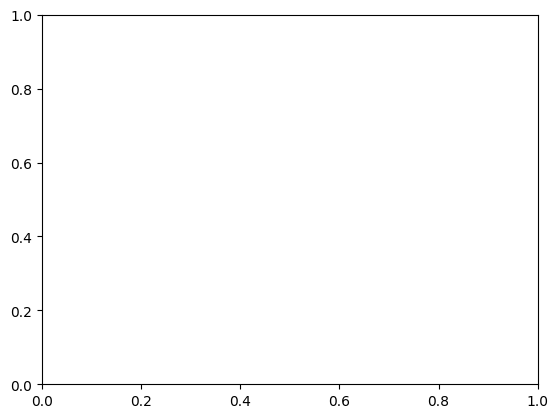

In [27]:
# Código
# Setup
import matplotlib.pyplot as plt

figure, ax = plt.subplots()

In [28]:
x = np.linspace(-np.pi, np.pi, 200)  # 200 pontos igualmente espaçados entre -pi e +pi

In [29]:
n = nusp_num  # 3
y = np.sin((n + 1) * x)  # y = sin((n+1)x)

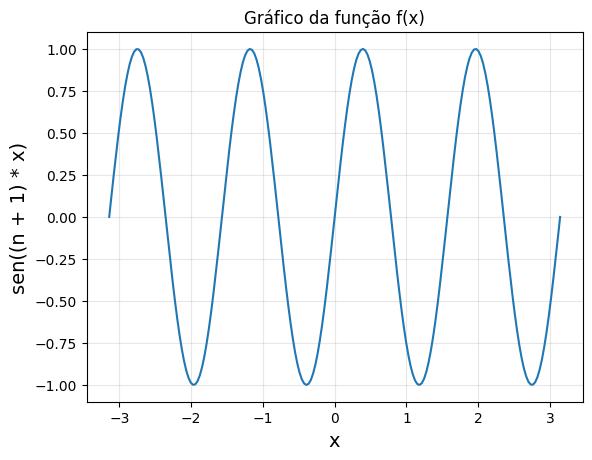

In [30]:
ax.plot(x, y)
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("sen((n + 1) * x)", fontsize=14)
ax.set_title("Gráfico da função f(x)")
ax.grid(alpha=0.3)
figure

In [31]:
ax.cla()
y_prime = (n + 1) * np.cos((n + 1) * x)

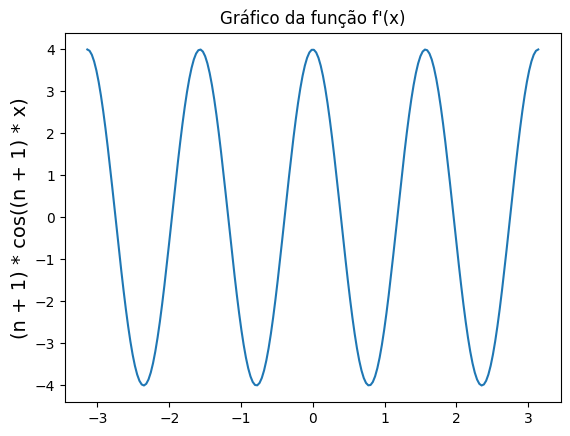

In [32]:
ax.plot(x, y_prime)
ax.set_ylabel("(n + 1) * cos((n + 1) * x)", fontsize=14)
ax.set_title("Gráfico da função f'(x)")
figure

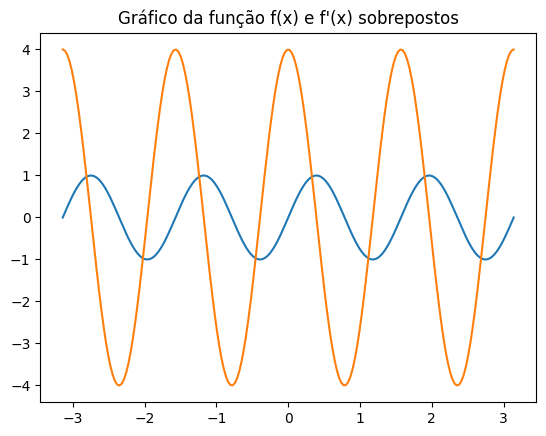

In [33]:
# Coloquei ambos sobrepostos também
ax.cla()
ax.plot(x, y)
ax.plot(x, y_prime)
ax.set_title("Gráfico da função f(x) e f'(x) sobrepostos")
figure

---

## Tópico Avançado (opcional)

#### Uso de memória

O tempo de execução é importante, mas o uso de memoria também é!

Vamos simplesmente guardar um tensor de ordem 3 (um "cubo", generalizando uma matriz) com

$$
R_{ijk}=\sqrt{i^2+j^2+k^2}
$$

In [34]:
# Matrizes - a forma ingênua
n = 100
R = np.empty((n, n, n))  # Um "cubo" vazio de n x n x n (um tensor de ordem 3)
start_time = time.time()
for i in range(n):
    for j in range(n):
        for k in range(n):
            R[i, j, k] = np.sqrt(
                i * i + j * j + k * k
            )  # Vamos guardar a raíz dos quadrados dos índices do tensor
tempo = time.time() - start_time
print("Com loops              : %s seconds " % tempo, " Memória auxiliar: ", 0.0, "MB")

NameError: name 'time' is not defined

O método acima é demorado, mas só foi necessário armazenar a matriz que nos interessa, sem variáveis auxiliares.

Podemos fazer isso mais rápido com vetorização, mas isso pode ter um custo de memória com variáveis auxiliares. Vejamos abaixo.

In [ ]:
# Alternativas - vetorização!
n = 100
# Usando mais memória
start_time = time.time()
# constroi cubos completos com valores de i, j, k
i, j, k = np.mgrid[:n, :n, :n]
R1 = np.sqrt(i**2 + j**2 + k**2)
tempo = time.time() - start_time
print(
    "Com grids auxiliares   : %s seconds " % tempo,
    " Memória auxiliar: ",
    3 * i.nbytes / 1024 / 1024,
    "MB",
)


# Ver se bateu
print(" Check:", np.max(np.max(np.max(np.abs(R1 - R)))))

Bem mais rápido, mas usamos mais memória...

Será que conseguimos fazer algo que não use tanta memória?

In [ ]:
# Usando menos memória
start_time = time.time()
# constroi vetores com valores de i, j, k
# Vetor i no sentido de "linha"/"largura"
i = np.arange(n).reshape(n, 1, 1)
# Vetor j no sentido de "coluna"/"altura"
j = np.reshape(i, (1, n, 1))
# Vetor k no sentido de "profundidade"
k = np.reshape(i, (1, 1, n))

# Alternativa para criar os 3 vetores acima de uma vez
# i, j, k = np.ogrid[:n, :n, :n]
R2 = np.sqrt(i**2 + j**2 + k**2)
tempo = time.time() - start_time
print(
    "Com vetores auxiliares : %s seconds " % tempo,
    " Memória auxiliar: ",
    3 * i.nbytes / 1024 / 1024,
    "MB",
)
print()

# Ver se bateu
print(" Check:", np.max(np.max(np.max(np.abs(R2 - R)))))

_A diferença de processamento e memória pode ser muito grande!_



---



  ### Cache e stride

**Cache**

Memória volátil (guarda coisas temporárias) de acesso rápido ao processador.

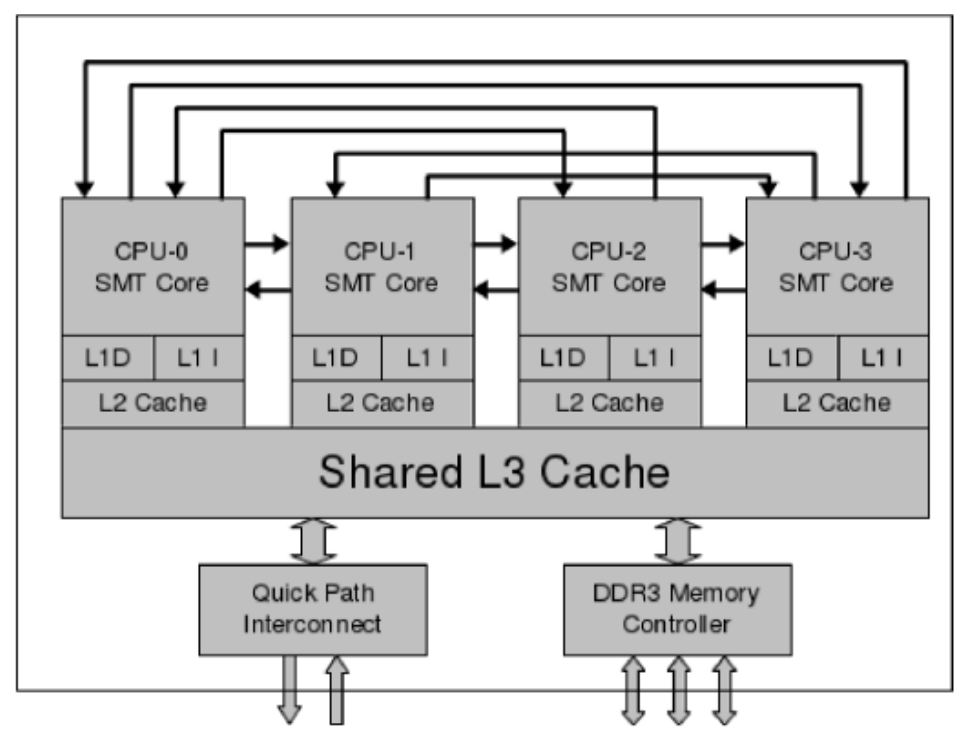

Intel Core i7 Processor Architechture Layout with Simultaneous Multi-threading (SMT)

https://fm.csl.sri.com/LAW09/2011/law2011-paper-bradetich.pdf


**Uso de memória**

Toda vez que passo um número da memória RAM para o processador fazer uma conta, ele não passa apenas esse número, mas tudo que tiver na memória em torno desse número (bloco) que caiba no cache!

_Exemplo idealizado:_

Caso 1:

    Memória tem os números guardados:
    3 , 7 , 8 , 23 , 54 , 77 , 40 , 45

    Quero fazer a conta 3 + 40, e a minha memória cache tem 2 blocos de memória, onde em cada um cabem 2 números por vez apenas, como o computador faz a conta?

    1) O processador pede o número 3 para a memória principal e salva o (3, 7) no bloco 1 cache

    2) O processador pede o número 40 para a memória principal e salva o (40, 45) no bloco 2 cache

    3) Os dois blocos levam as informações para os registradores do processador, e dependendo do processador, ele faz a conta de forma vetorial (3,7) + (40, 45) e retorna (43, 52), sendo o valor 43 salvo na memória RAM no endereço solicitado.
    
    4) Agora, se queremos fazer a conta 8 + 45, o processador pede para jogarem fora o bloco 1 do cache e preencher com (8, 23) para fazer a nova conta, usando o bloco 2 já salvo no cache.
    
    
Caso 2:

    Memória tem os números guardados (vejam a troca do 7 pelo 8):
    3 , 8 , 7 , 23 , 54 , 77 , 40 , 45

    Quero fazer a conta 3 + 40, e a minha memória cache tem 2 blocos de memória, onde em cada um cabem 2 números por vez apenas, como o computador faz a conta?

    1) O processador pede o número 3 para a memória principal e salva o (3, 8) no bloco 1 cache

    2) O processador pede o número 40 para a memória principal e salva o (40, 45) no bloco 2 cache

    3) Os dois blocos levam as informações para os registradores do processador, e dependendo do processador, ele faz a conta de forma vetorial (3,8) + (40, 45) e retorna (43, 53), sendo o valor 43 salvo na memória RAM no endereço solicitado.
    
    4) Agora, se queremos fazer a conta 8 + 45, o processador já percebe que as informações relevantes estão em cache, e a conta da operação é aproveitada, devolvendo o 53 na memória (caso o processador seja vetorial). Ou então, para um processador não vetorial, ele já tem as informações para fazer a conta rapidamente, sem precisar acessar a RAM!
    
**Alinhamento de memória**

As contas devem ser preferencialmente feitas na ordem em que os dados estão na memória!!!! Quando o processador precisa ficar pedindo novos dados à RAM dizemos que está ocorrendo muito __cache miss__

O caso de um computador real é um pouco mais complicado, mas esse conceito ainda é válido. Mais detalhes em https://courses.cs.washington.edu/courses/cse378/09wi/lectures/lec15.pdf


### Matrizes na memória

In [ ]:
#Matriz
import numpy as np

n = 20000
c = np.ones((n, 2*n))
linhas, colunas = c.shape
print("Matriz: ", c.shape, "\n", c)
print()

#Soma, para cada coluna, os valores das linhas primeiro
#Código ingênuo
#s = 0
#for j in range(colunas):
#    for i in range(linhas):
#        s = s + c[i,j]
#Código vetorizado
%time s = np.sum(c.sum(axis=0)) #axis=0 significa que vai soma as linhas para cada coluna primeiro!
print("Soma coluna a coluna:", s)
print()

#Soma, para cada linha, os valores das colunas primeiro
#Código ingênuo
#s = 0
#for i in range(linhas):
#    for j in range(colunas):
#        s = s + c[i,j]
#Código vetorizado
%time s = np.sum(c.sum(axis=1)) #axis=1  significa que vai somar nas colunas primeiro
print("Soma linha a linha: ", s)
print()



Se ele vai mais rápido somando primeiro as colunas de cada linha, então ele deve armazenar na ordem de linhas!! Isso é chamado de ordem no estilo "C" (padrão em Python) - Row-major order

Ordem C:

         -------------------
         -------------------
         -------------------
         -------------------
         -------------------
         
É possível pedir para o Python armazenar de outro jeito, a ordem no estilo Fortran - Column-major order

Ordem Fortran:

               | | | | | | | |
               | | | | | | | |
               | | | | | | | |               
               | | | | | | | |
               | | | | | | | |               


Mais info em : https://scipy-lectures.org/advanced/advanced_numpy/index.html#cache-effects

Ordem C (por linhas):

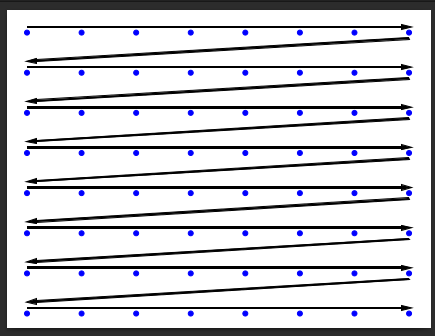

Ordem Fortran (por colunas):

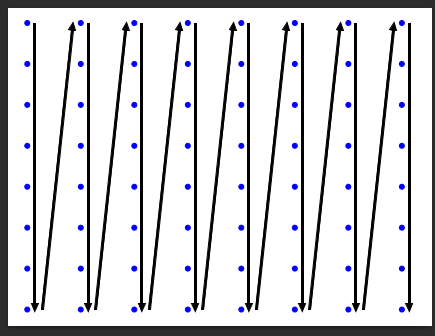

In [ ]:
#Repetindo o exemplo anterior com ordem Fortran

#Matriz
import numpy as np

n = 10000
c = np.ones((n, 2*n), order='F')
linhas, colunas = c.shape
print("Matriz: ", c.shape, "\n", c)
print()

#Soma, para cada coluna, os valores das linhas primeiro
#Código ingênuo
#s = 0
#for j in range(colunas):
#    for i in range(linhas):
#        s = s + c[i,j]
#Código vetorizado
%time s = np.sum(c.sum(axis=0)) #axis=0 significa que vai soma as linhas para cada coluna primeiro!
print("Soma coluna a coluna:", s)
print()

#Soma, para cada linha, os valores das colunas primeiro
#Código ingênuo
#s = 0
#for i in range(linhas):
#    for j in range(colunas):
#        s = s + c[i,j]
#Código vetorizado
%time s = np.sum(c.sum(axis=1)) #axis=1  significa que vai somar nas colunas primeiro
print("Soma linha a linha: ", s)
print()


Note que agora ficou mais rápido lendo coluna a coluna (significa que vai somar as linhas para cada coluna primeiro!)!

### Stride e sua relação com cache miss

Strides: número de bytes para pular na memória até chegar no próximo elemento.

Exemplo: Uma matrix 10x10 com stride de (10,1) significa que:
- Para chegar na próxima linha tem que pular 10 bytes
- Para chegar na próxima coluna, basta olhar o próximo byte

Logo, isso está fortemente conectado ao conceito visto antes de ordenamento.


In [ ]:
# Cada inteiro neste caso foi forçado a ocupar 2 bytes na memória (16 bits). 1 byte = 8 bits
x = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=np.int16, order="C")

print("Ordem C: ", x.strides)

x = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=np.int16, order="F")

print("Ordem F: ", x.strides)

Logo, no Python podemos especificar a ordem de armazenamento dos elementos de uma matriz para aumentar a eficiência do código.